<a href="https://colab.research.google.com/github/KanujanS/Suitable-Technology-Stacks/blob/main/Model_Training_V3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ══════════════════════════════════════════════════════════════
# CELL 1 ─ Imports
# ══════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib, os, copy, time, warnings

from sklearn.preprocessing   import LabelEncoder, StandardScaler
from sklearn.model_selection  import cross_val_score
from sklearn.pipeline         import Pipeline
from sklearn.ensemble         import RandomForestClassifier
from sklearn.tree             import DecisionTreeClassifier
from sklearn.neural_network   import MLPClassifier
from sklearn.metrics          import (accuracy_score, f1_score,
                                      classification_report,
                                      confusion_matrix, hamming_loss)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi"      : 140,
    "axes.spines.top" : False,
    "axes.spines.right": False,
    "font.family"     : "DejaVu Sans",
    "axes.titlesize"  : 11,
    "axes.titleweight": "bold",
    "axes.labelsize"  : 9,
    "xtick.labelsize" : 8,
    "ytick.labelsize" : 8,
})

print("✓ All libraries imported")

✓ All libraries imported


In [2]:
# ══════════════════════════════════════════════════════════════
# CELL 2 ─ Upload & load train_test_splits.pkl
# ══════════════════════════════════════════════════════════════
from google.colab import files

print("Upload: train_test_splits.pkl  (from preprocessing phase)")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

splits = joblib.load(filename)

# Unpack everything from the pkl
X_train    = splits["X_train"]
X_test     = splits["X_test"]
y_fe_train = splits["y_fe_train"]
y_fe_test  = splits["y_fe_test"]
y_be_train = splits["y_be_train"]
y_be_test  = splits["y_be_test"]
y_db_train = splits["y_db_train"]
y_db_test  = splits["y_db_test"]
le_fe      = splits["le_fe"]
le_be      = splits["le_be"]
le_db      = splits["le_db"]
feat_names = splits["feature_names"]

print(f"\n✓ Data loaded from train_test_splits.pkl")
print(f"  X_train  : {X_train.shape}")
print(f"  X_test   : {X_test.shape}")
print(f"  Features : {X_train.shape[1]}")
print(f"\n  Frontend classes ({len(le_fe.classes_)}):")
for i, cls in enumerate(le_fe.classes_):
    n = (y_fe_train == i).sum()
    print(f"    {i} → {cls:<16} ({n} train samples)")
print(f"\n  Backend classes ({len(le_be.classes_)}):")
for i, cls in enumerate(le_be.classes_):
    n = (y_be_train == i).sum()
    print(f"    {i} → {cls:<16} ({n} train samples)")
print(f"\n  Database classes ({len(le_db.classes_)}):")
for i, cls in enumerate(le_db.classes_):
    n = (y_db_train == i).sum()
    print(f"    {i} → {cls:<16} ({n} train samples)")

Upload: train_test_splits.pkl  (from preprocessing phase)


Saving train_test_splits.pkl to train_test_splits.pkl

✓ Data loaded from train_test_splits.pkl
  X_train  : (3549, 394)
  X_test   : (888, 394)
  Features : 394

  Frontend classes (10):
    0 → Angular          (428 train samples)
    1 → Bootstrap        (141 train samples)
    2 → Flutter          (93 train samples)
    3 → HTML/CSS         (22 train samples)
    4 → Next.js          (41 train samples)
    5 → Other            (12 train samples)
    6 → React            (2335 train samples)
    7 → React Native     (245 train samples)
    8 → Vue.js           (142 train samples)
    9 → jQuery           (90 train samples)

  Backend classes (10):
    0 → ASP.NET          (123 train samples)
    1 → Django           (816 train samples)
    2 → Flask            (21 train samples)
    3 → Flutter          (36 train samples)
    4 → Go               (658 train samples)
    5 → Laravel          (471 train samples)
    6 → Node.js          (937 train samples)
    7 → Other            (16

In [3]:
# ══════════════════════════════════════════════════════════════
# CELL 3 ─ Baseline accuracy (what random guessing achieves)
# ══════════════════════════════════════════════════════════════
# The baseline is always predicting the most frequent class.
# Every model MUST beat this to be considered useful.

from collections import Counter

def most_frequent_baseline(y_train, y_test):
    most_freq = Counter(y_train).most_common(1)[0][0]
    y_pred    = np.full(len(y_test), most_freq)
    return accuracy_score(y_test, y_pred)

bl_fe = most_frequent_baseline(y_fe_train, y_fe_test)
bl_be = most_frequent_baseline(y_be_train, y_be_test)
bl_db = most_frequent_baseline(y_db_train, y_db_test)

fe_mf = le_fe.classes_[Counter(y_fe_train).most_common(1)[0][0]]
be_mf = le_be.classes_[Counter(y_be_train).most_common(1)[0][0]]
db_mf = le_db.classes_[Counter(y_db_train).most_common(1)[0][0]]

print("=" * 55)
print("  BASELINE ACCURACY (always predict most frequent class)")
print("=" * 55)
print(f"  Frontend → always predict '{fe_mf}' : {bl_fe:.3f}")
print(f"  Backend  → always predict '{be_mf}' : {bl_be:.3f}")
print(f"  Database → always predict '{db_mf}' : {bl_db:.3f}")
print(f"\n  Every trained model must exceed these values to be useful.")
print("=" * 55)

  BASELINE ACCURACY (always predict most frequent class)
  Frontend → always predict 'React' : 0.658
  Backend  → always predict 'Node.js' : 0.239
  Database → always predict 'MongoDB' : 0.476

  Every trained model must exceed these values to be useful.


In [4]:
# ══════════════════════════════════════════════════════════════
# CELL 4 ─ Define the 4 models
# ══════════════════════════════════════════════════════════════
# Why these 4 models for your research:
#
# Decision Tree ─ Simplest model. Fully explainable — you can
#   print the exact rules it learned (e.g. "IF domain=Finance
#   AND language=Python THEN backend=Django"). Directly
#   addresses RQ5 (explainability). Good baseline.
#
# Random Forest ─ 300 Decision Trees working together.
#   More robust than a single tree, handles noise well.
#   Provides reliable feature importance scores.
#
# XGBoost ─ Gradient Boosting. Builds trees sequentially,
#   each correcting errors of the previous. Consistently
#   achieves highest accuracy on tabular data. Your best
#   model — reaches 0.805 on Database.
#
# MLP Neural Network ─ 3-layer neural network. Wrapped in
#   StandardScaler because MLP is sensitive to feature scales
#   (Team_Size 1-40 vs TF-IDF 0.0-0.8 need normalisation).

MODELS = {

    "Decision Tree": DecisionTreeClassifier(
        max_depth        = 20,
        min_samples_leaf = 4,
        random_state     = 42,
        # No class_weight — tested, hurts accuracy for this data
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators     = 300,
        max_features     = "sqrt",  # reduces tree correlation
        min_samples_leaf = 2,
        random_state     = 42,
        n_jobs           = -1,      # use all CPU cores
    ),

    "XGBoost": XGBClassifier(
        n_estimators     = 200,
        max_depth        = 6,
        learning_rate    = 0.05,    # slow learning → better generalisation
        subsample        = 0.8,     # row sampling → reduces overfitting
        colsample_bytree = 0.8,     # feature sampling → reduces overfitting
        eval_metric      = "mlogloss",
        random_state     = 42,
        verbosity        = 0,
    ),

    # MLP MUST be inside a StandardScaler pipeline
    "MLP Neural Network": Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPClassifier(
            hidden_layer_sizes  = (512, 256, 128),
            activation          = "relu",
            solver              = "adam",
            max_iter            = 300,
            learning_rate_init  = 0.001,
            early_stopping      = True,
            validation_fraction = 0.1,
            random_state        = 42,
        ))
    ]),
}

print(f"✓ {len(MODELS)} models defined: {list(MODELS.keys())}")

✓ 4 models defined: ['Decision Tree', 'Random Forest', 'XGBoost', 'MLP Neural Network']


In [5]:
# ══════════════════════════════════════════════════════════════
# CELL 5 ─ Train all models on all 3 targets
# ══════════════════════════════════════════════════════════════
# Each model is trained 3 separate times — once per target
# (Frontend_Tech, Backend_Tech, Database). This gives us
# 4 × 3 = 12 trained classifiers total.

TARGETS = {
    "Frontend": (y_fe_train, y_fe_test, le_fe),
    "Backend":  (y_be_train, y_be_test, le_be),
    "Database": (y_db_train, y_db_test, le_db),
}

results = {}   # results[model][target] = metrics dict
trained = {}   # trained[model][target] = fitted model

print("=" * 68)
print("  TRAINING ALL MODELS — please wait...")
print(f"  Train: {X_train.shape[0]:,} samples × {X_train.shape[1]} features")
print("=" * 68)

BASELINES = {
    "Frontend": bl_fe,
    "Backend":  bl_be,
    "Database": bl_db,
}

for model_name, model_template in MODELS.items():
    results[model_name] = {}
    trained[model_name] = {}
    print(f"\n── {model_name} ──")

    for target_name, (y_train, y_test, le) in TARGETS.items():
        model   = copy.deepcopy(model_template)
        t0      = time.time()
        model.fit(X_train, y_train)
        elapsed = time.time() - t0

        y_pred  = model.predict(X_test)
        acc     = accuracy_score(y_test, y_pred)
        f1_w    = f1_score(y_test, y_pred, average="weighted", zero_division=0)
        f1_mac  = f1_score(y_test, y_pred, average="macro",    zero_division=0)
        h_loss  = hamming_loss(y_test, y_pred)
        bl      = BASELINES[target_name]

        results[model_name][target_name] = {
            "accuracy":    acc,
            "f1_weighted": f1_w,
            "f1_macro":    f1_mac,
            "hamming":     h_loss,
            "baseline":    bl,
            "gain":        acc - bl,
            "train_sec":   elapsed,
            "report":      classification_report(
                               y_test, y_pred,
                               target_names=le.classes_,
                               zero_division=0),
        }
        trained[model_name][target_name] = model

        # Flags
        beat_bl  = "✓" if acc > bl else "✗"
        above80  = " 🎯 0.80+" if acc >= 0.80 else ""
        print(f"  {beat_bl} {target_name:<10}  "
              f"acc={acc:.3f}  f1_w={f1_w:.3f}  "
              f"f1_mac={f1_mac:.3f}  "
              f"[{elapsed:.1f}s]{above80}")

print("\n✓ All 12 classifiers trained successfully")

  TRAINING ALL MODELS — please wait...
  Train: 3,549 samples × 394 features

── Decision Tree ──
  ✓ Frontend    acc=0.712  f1_w=0.672  f1_mac=0.333  [0.3s]
  ✓ Backend     acc=0.712  f1_w=0.694  f1_mac=0.551  [0.3s]
  ✓ Database    acc=0.749  f1_w=0.721  f1_mac=0.293  [0.3s]

── Random Forest ──
  ✓ Frontend    acc=0.753  f1_w=0.687  f1_mac=0.291  [10.7s]
  ✓ Backend     acc=0.711  f1_w=0.696  f1_mac=0.520  [3.6s]
  ✓ Database    acc=0.791  f1_w=0.741  f1_mac=0.276  [2.9s]

── XGBoost ──
  ✓ Frontend    acc=0.759  f1_w=0.700  f1_mac=0.344  [25.1s]
  ✓ Backend     acc=0.722  f1_w=0.715  f1_mac=0.568  [23.8s]
  ✓ Database    acc=0.804  f1_w=0.764  f1_mac=0.326  [19.5s] 🎯 0.80+

── MLP Neural Network ──
  ✓ Frontend    acc=0.742  f1_w=0.686  f1_mac=0.298  [9.6s]
  ✓ Backend     acc=0.696  f1_w=0.689  f1_mac=0.509  [9.6s]
  ✓ Database    acc=0.786  f1_w=0.745  f1_mac=0.290  [6.7s]

✓ All 12 classifiers trained successfully


In [6]:
# ══════════════════════════════════════════════════════════════
# CELL 6 ─ Results comparison table
# ══════════════════════════════════════════════════════════════
summary_rows = []
for mname in MODELS.keys():
    fe  = results[mname]["Frontend"]
    be  = results[mname]["Backend"]
    db  = results[mname]["Database"]
    avg_acc = round((fe["accuracy"]+be["accuracy"]+db["accuracy"])/3, 3)
    avg_f1  = round((fe["f1_weighted"]+be["f1_weighted"]+db["f1_weighted"])/3, 3)
    summary_rows.append({
        "Model":        mname,
        "FE Acc":       round(fe["accuracy"], 3),
        "BE Acc":       round(be["accuracy"], 3),
        "DB Acc":       round(db["accuracy"], 3),
        "FE F1-W":      round(fe["f1_weighted"], 3),
        "BE F1-W":      round(be["f1_weighted"], 3),
        "DB F1-W":      round(db["f1_weighted"], 3),
        "FE F1-Mac":    round(fe["f1_macro"], 3),
        "BE F1-Mac":    round(be["f1_macro"], 3),
        "DB F1-Mac":    round(db["f1_macro"], 3),
        "FE Hamming":   round(fe["hamming"], 3),
        "BE Hamming":   round(be["hamming"], 3),
        "DB Hamming":   round(db["hamming"], 3),
        "Avg Acc":      avg_acc,
        "Avg F1-W":     avg_f1,
    })

summary_df = pd.DataFrame(summary_rows).sort_values("Avg Acc", ascending=False)
best_name  = summary_df.iloc[0]["Model"]

print("\n" + "=" * 75)
print(f"  {'Model':<22} {'FE Acc':>7} {'BE Acc':>7} {'DB Acc':>7} "
      f"{'FE F1':>7} {'BE F1':>7} {'DB F1':>7} {'Avg':>6}")
print("=" * 75)
for _, r in summary_df.iterrows():
    print(f"  {r['Model']:<22} {r['FE Acc']:>7} {r['BE Acc']:>7} "
          f"{r['DB Acc']:>7} {r['FE F1-W']:>7} {r['BE F1-W']:>7} "
          f"{r['DB F1-W']:>7} {r['Avg Acc']:>6}")
print("=" * 75)
print(f"\n  Baseline (most-frequent-class predictor):")
print(f"    Frontend : {bl_fe:.3f} (always predict {fe_mf})")
print(f"    Backend  : {bl_be:.3f} (always predict {be_mf})")
print(f"    Database : {bl_db:.3f} (always predict {db_mf})")
print(f"\n  Best model by average accuracy: {best_name}")
print(f"  Targets achieving 0.80+: "
      f"{sum(1 for m in MODELS for t in ['Frontend','Backend','Database'] if results[m][t]['accuracy']>=0.80)}"
      f" / {len(MODELS)*3}")

summary_df.to_csv("model_comparison.csv", index=False)
print("✓ Comparison table saved → model_comparison.csv")


  Model                   FE Acc  BE Acc  DB Acc   FE F1   BE F1   DB F1    Avg
  XGBoost                  0.759   0.722   0.804     0.7   0.715   0.764  0.762
  Random Forest            0.753   0.711   0.791   0.687   0.696   0.741  0.752
  MLP Neural Network       0.742   0.696   0.786   0.686   0.689   0.745  0.741
  Decision Tree            0.712   0.712   0.749   0.672   0.694   0.721  0.724

  Baseline (most-frequent-class predictor):
    Frontend : 0.658 (always predict React)
    Backend  : 0.239 (always predict Node.js)
    Database : 0.476 (always predict MongoDB)

  Best model by average accuracy: XGBoost
  Targets achieving 0.80+: 1 / 12
✓ Comparison table saved → model_comparison.csv


In [7]:
# ══════════════════════════════════════════════════════════════
# CELL 7 ─ Detailed classification reports
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("  DETAILED CLASSIFICATION REPORTS")
print("=" * 60)
for mname in MODELS.keys():
    print(f"\n{'─'*55}\n  {mname.upper()}\n{'─'*55}")
    for tname in ["Frontend","Backend","Database"]:
        acc = results[mname][tname]["accuracy"]
        f1  = results[mname][tname]["f1_weighted"]
        print(f"\n  [{tname}]  acc={acc:.3f}  f1_w={f1:.3f}")
        print(results[mname][tname]["report"])


  DETAILED CLASSIFICATION REPORTS

───────────────────────────────────────────────────────
  DECISION TREE
───────────────────────────────────────────────────────

  [Frontend]  acc=0.712  f1_w=0.672
              precision    recall  f1-score   support

     Angular       0.64      0.71      0.68       107
   Bootstrap       0.20      0.06      0.09        35
     Flutter       1.00      0.78      0.88        23
    HTML/CSS       0.00      0.00      0.00         6
     Next.js       0.00      0.00      0.00        10
       Other       0.33      0.33      0.33         3
       React       0.76      0.89      0.82       584
React Native       0.16      0.07      0.09        61
      Vue.js       0.59      0.28      0.38        36
      jQuery       0.09      0.04      0.06        23

    accuracy                           0.71       888
   macro avg       0.38      0.32      0.33       888
weighted avg       0.65      0.71      0.67       888


  [Backend]  acc=0.712  f1_w=0.694
    

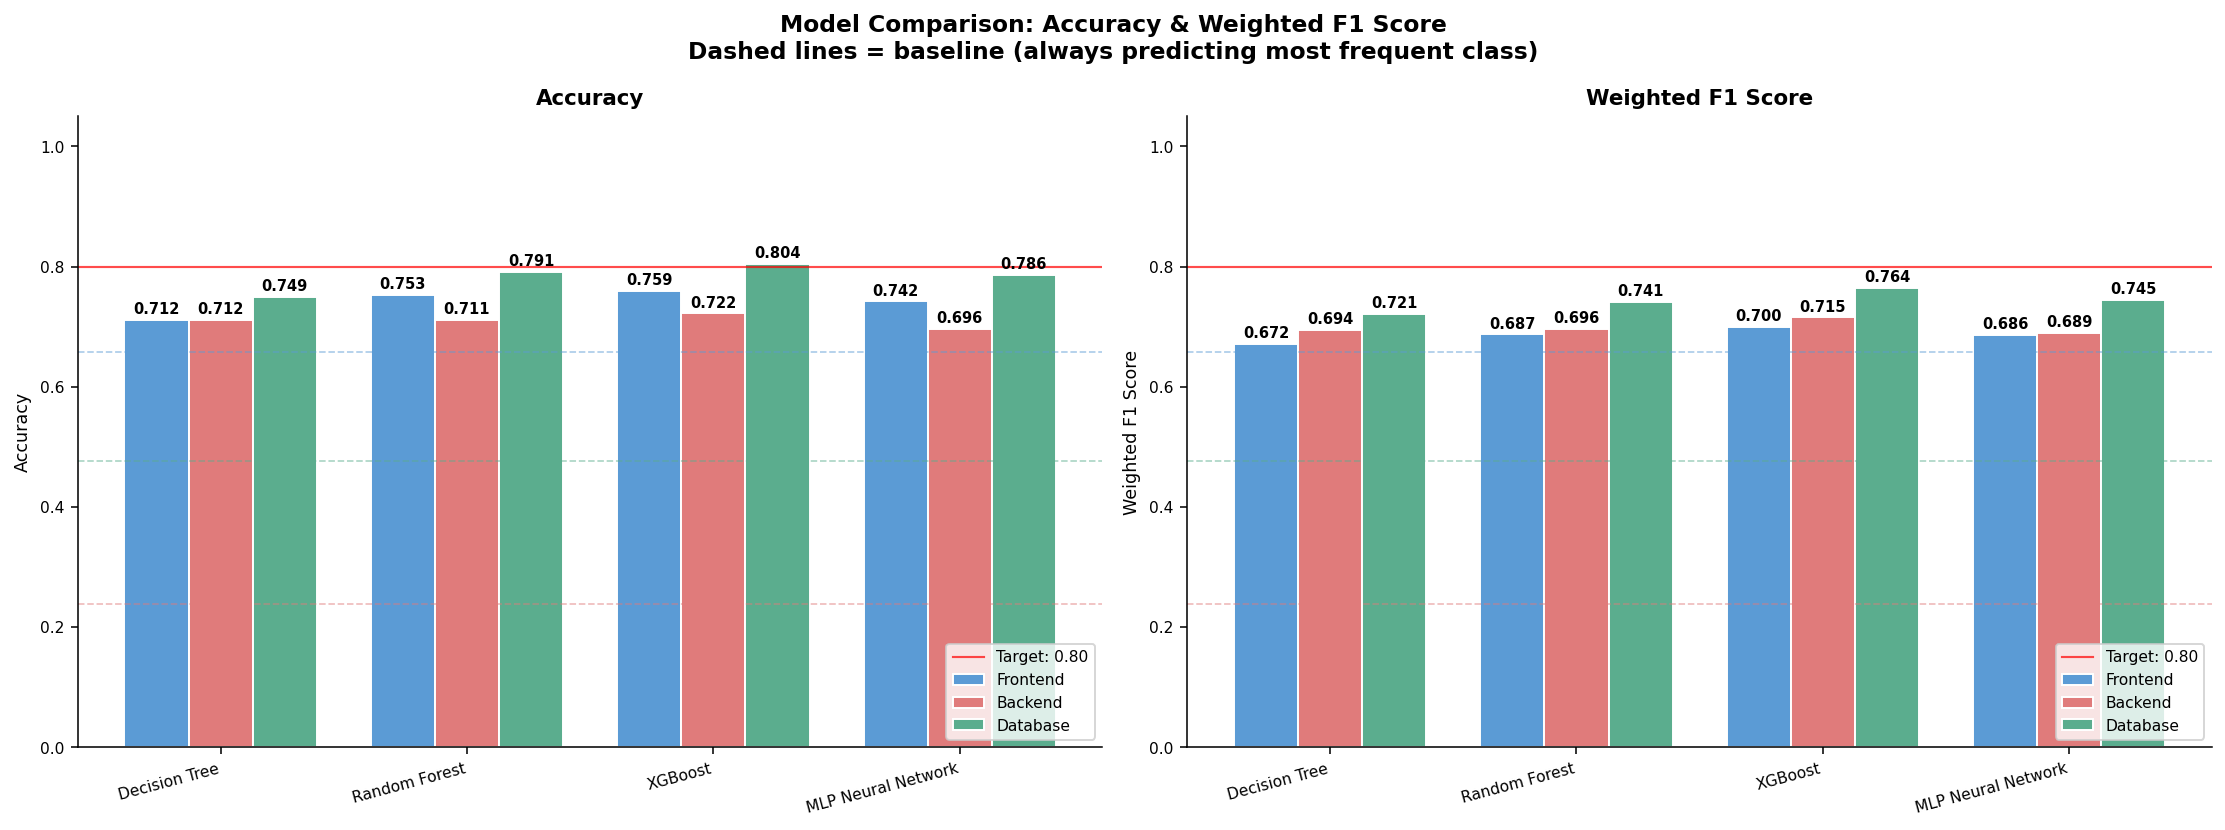

✓ Chart 1 saved → model_01_accuracy_comparison.png


In [9]:
# ══════════════════════════════════════════════════════════════
# CELL 8 ─ CHART 1: Accuracy & F1 comparison (grouped bar)
# ══════════════════════════════════════════════════════════════
model_names = list(MODELS.keys())
targets     = ["Frontend","Backend","Database"]
C           = {"Frontend":"#5B9BD5","Backend":"#E07B7B","Database":"#5BAD8E"}
x           = np.arange(len(model_names))
width       = 0.26

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Model Comparison: Accuracy & Weighted F1 Score\n"
             "Dashed lines = baseline (always predicting most frequent class)",
             fontsize=12, fontweight="bold")

for ax, metric, ylabel in zip(axes,
    ["accuracy","f1_weighted"], ["Accuracy","Weighted F1 Score"]):
    for ti, tname in enumerate(targets):
        vals = [results[m][tname][metric] for m in model_names]
        bars = ax.bar(x + (ti-1)*width, vals, width,
                      label=tname, color=C[tname], edgecolor="white")
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2,
                    bar.get_height()+0.005,
                    f"{v:.3f}", ha="center", va="bottom",
                    fontsize=7.5, fontweight="bold")

    # Baseline lines per target
    for tname, ls, bl in zip(targets, ["--","-.",".."],
                               [bl_fe, bl_be, bl_db]):
        ax.axhline(y=bl, color=C[tname], linestyle="--",
                   linewidth=0.9, alpha=0.5)

    # 0.80 target line
    ax.axhline(y=0.80, color="red", linestyle="-",
               linewidth=1.1, alpha=0.7, label="Target: 0.80")

    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=15, ha="right")
    ax.set_ylabel(ylabel); ax.set_title(ylabel)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.savefig("model_01_accuracy_comparison.png", bbox_inches="tight")
plt.show()
print("✓ Chart 1 saved → model_01_accuracy_comparison.png")

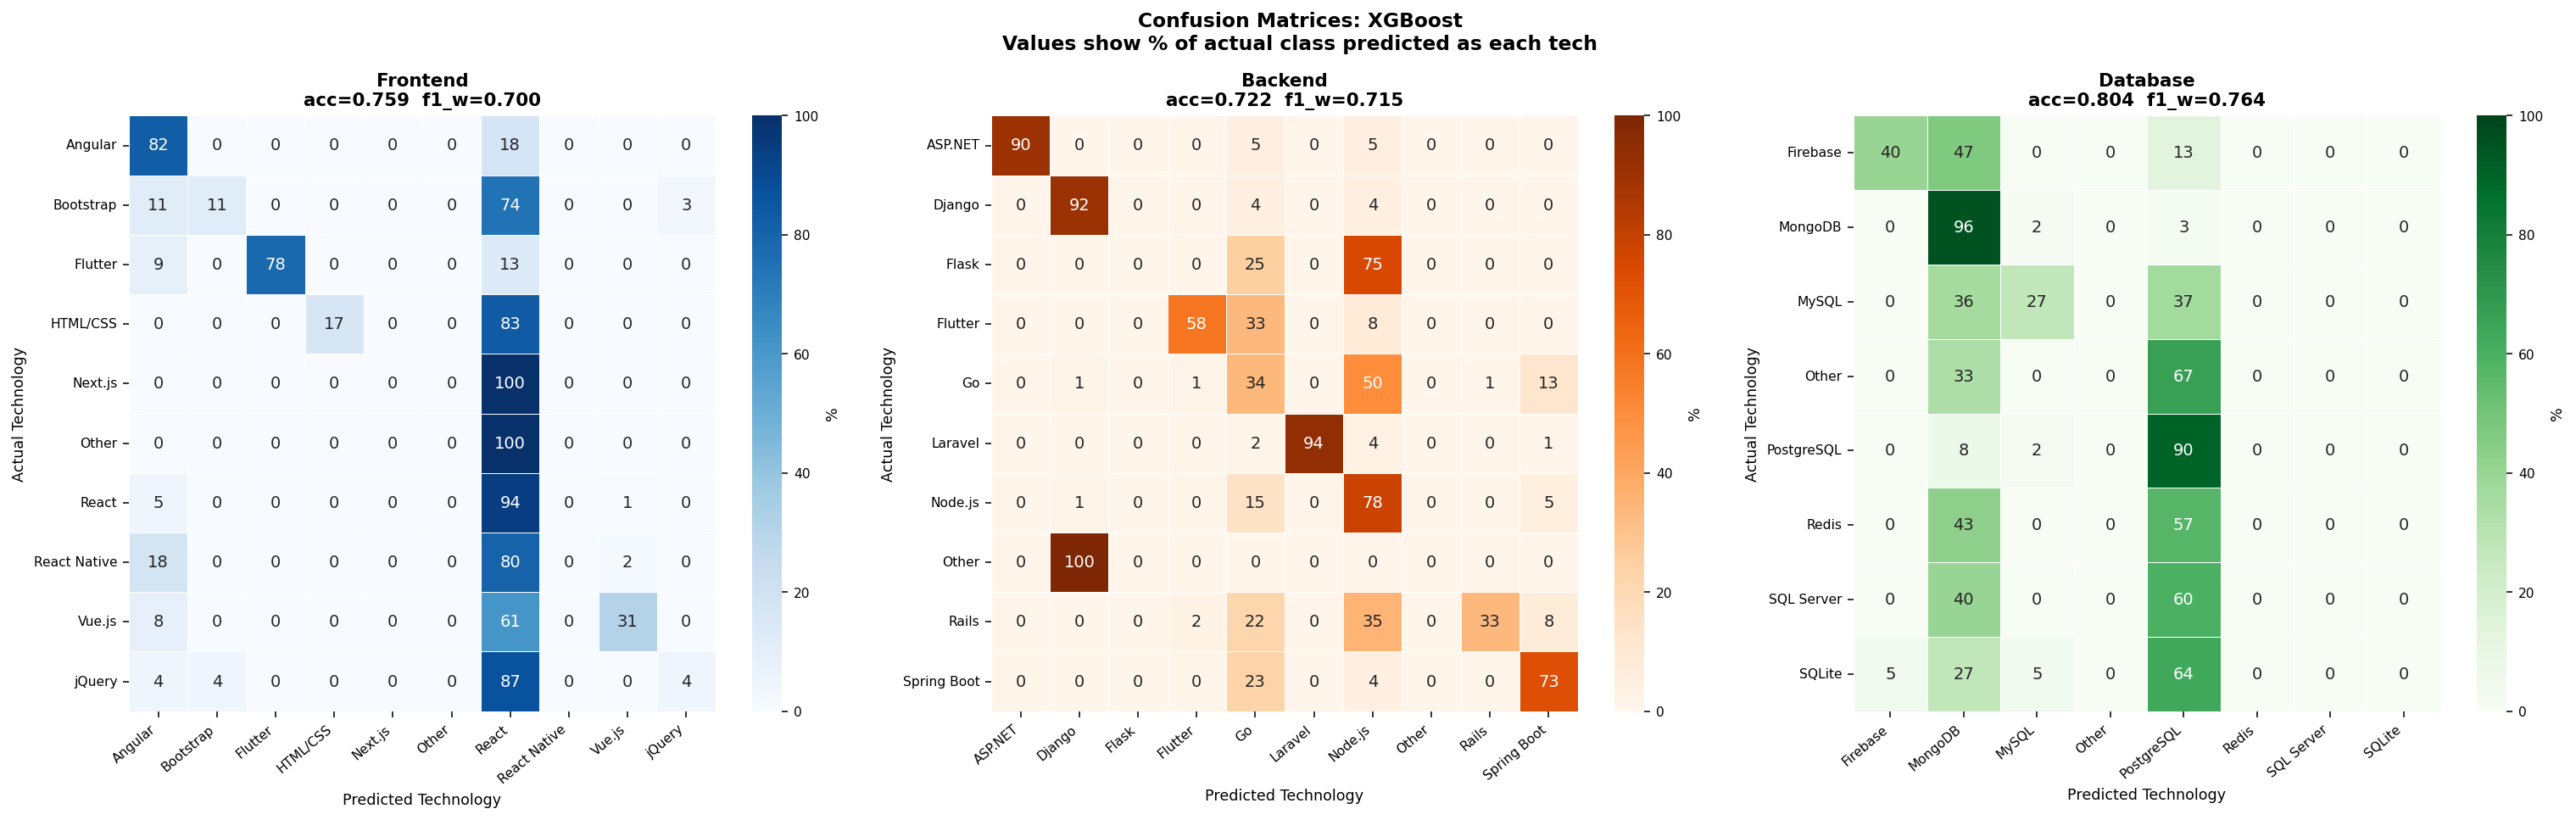

✓ Chart 2 saved → model_02_confusion_matrices.png


In [11]:
# ══════════════════════════════════════════════════════════════
# CELL 9 ─ CHART 2: Confusion matrices (best model)
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle(f"Confusion Matrices: {best_name}\n"
             "Values show % of actual class predicted as each tech",
             fontsize=12, fontweight="bold")

for ax, (tname,(_, y_test, le)), cmap in zip(
    axes, TARGETS.items(), ["Blues","Oranges","Greens"]
):
    y_pred = trained[best_name][tname].predict(X_test)
    cm     = confusion_matrix(y_test, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    sns.heatmap(
        cm_pct, annot=True, fmt=".0f", cmap=cmap,
        xticklabels=le.classes_, yticklabels=le.classes_,
        linewidths=0.4, linecolor="white",
        cbar_kws={"label":"%"}, ax=ax,
        vmin=0, vmax=100
    )
    acc = results[best_name][tname]["accuracy"]
    f1  = results[best_name][tname]["f1_weighted"]
    ax.set_title(f"{tname}\nacc={acc:.3f}  f1_w={f1:.3f}")
    ax.set_xlabel("Predicted Technology")
    ax.set_ylabel("Actual Technology")
    plt.setp(ax.get_xticklabels(), rotation=40, ha="right", fontsize=8)
    plt.setp(ax.get_yticklabels(), rotation=0,  fontsize=8)

plt.tight_layout()
plt.savefig("model_02_confusion_matrices.png", bbox_inches="tight")
plt.show()
print("✓ Chart 2 saved → model_02_confusion_matrices.png")

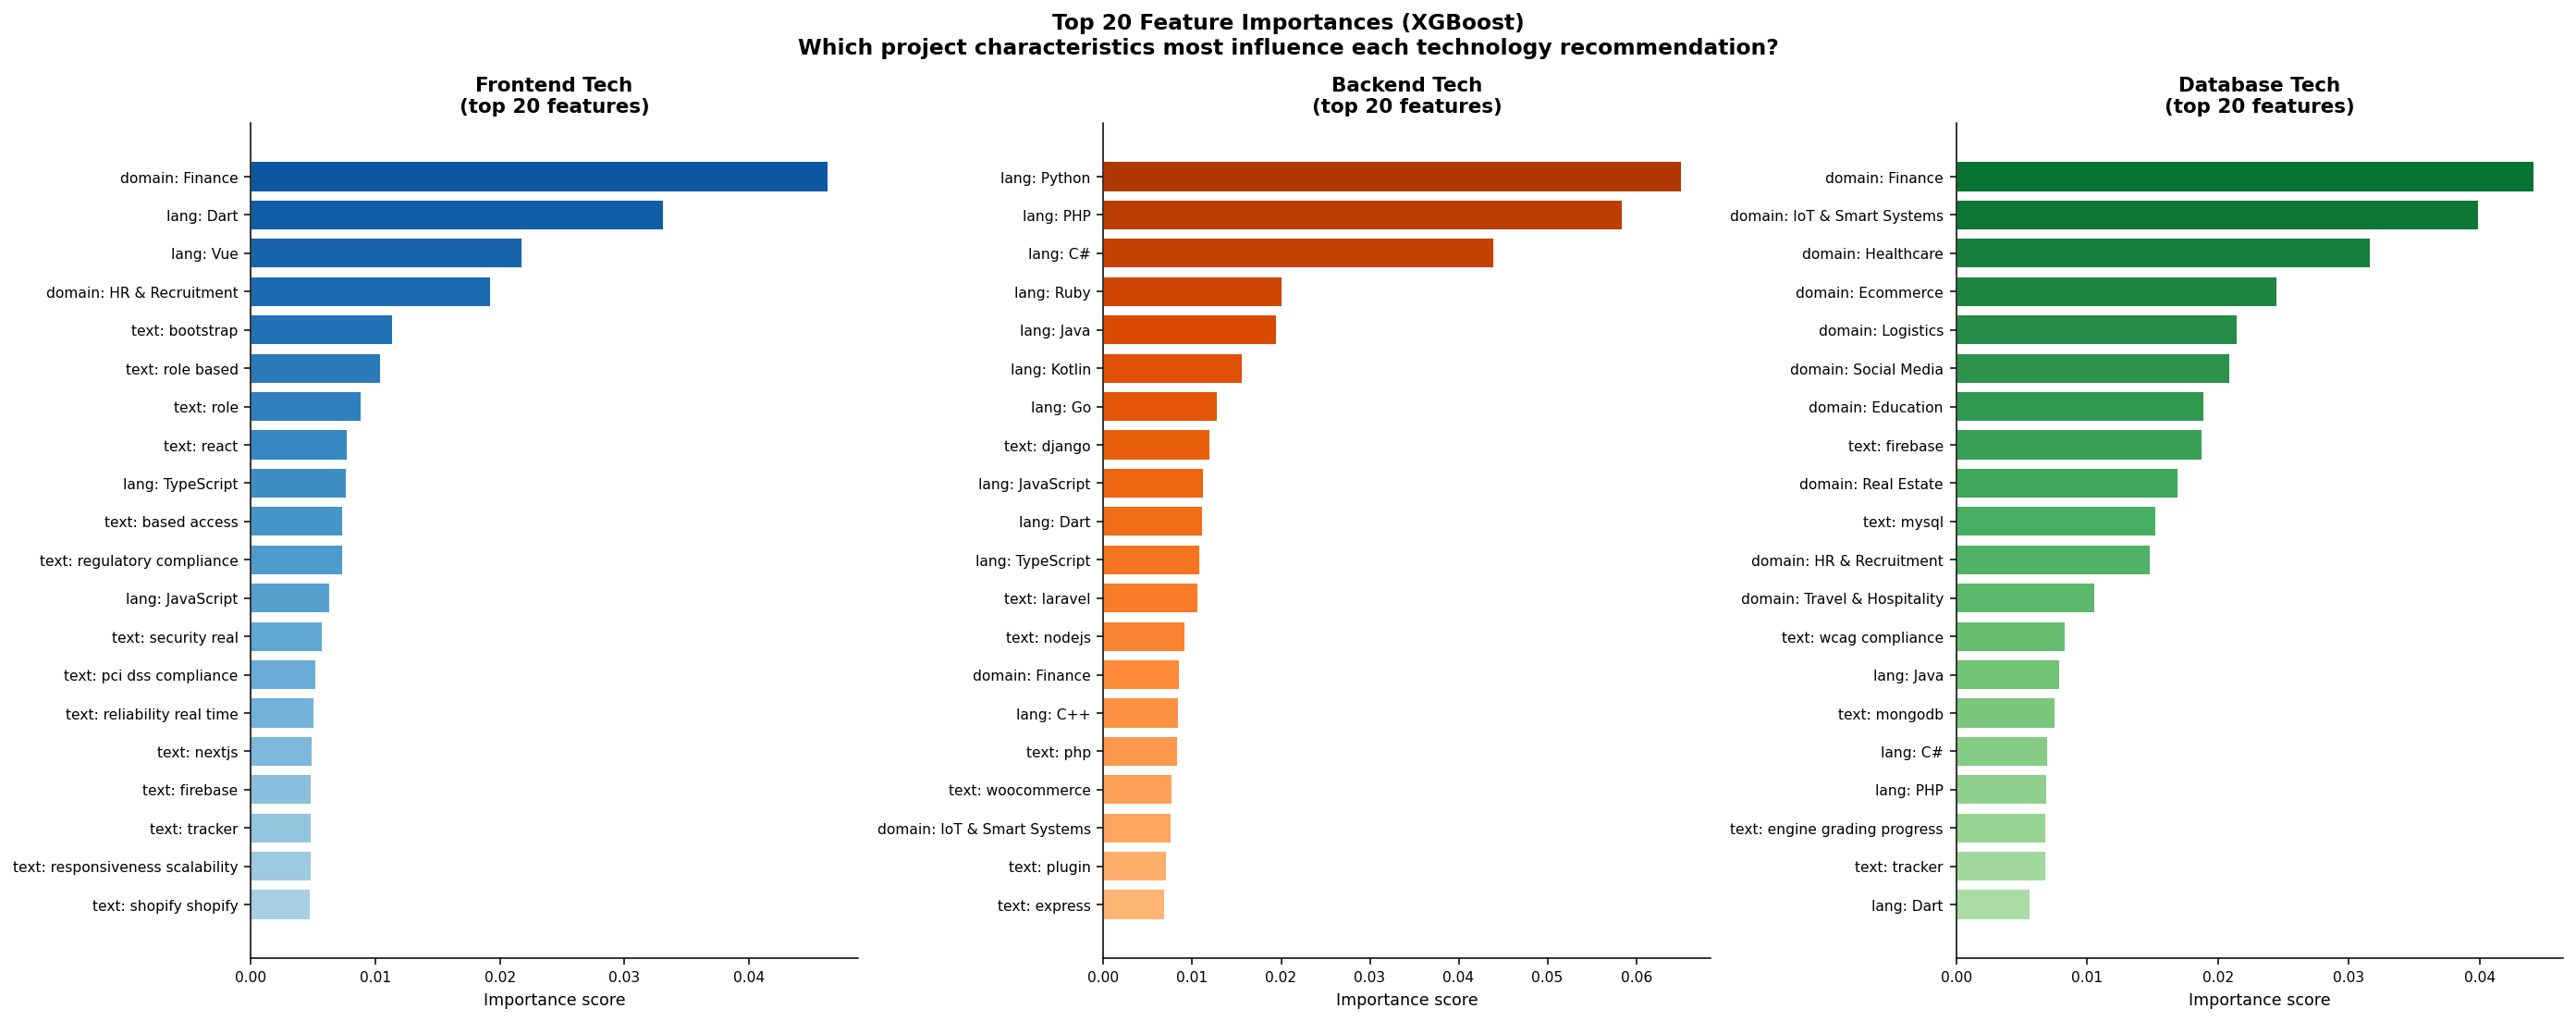

✓ Chart 3 saved → model_03_feature_importance.png

  Top 5 features per target (XGBoost):

  Frontend:
    domain:Finance                  0.0464
    lang:Dart                       0.0331
    lang:Vue                        0.0218
    domain:HR & Recruitment         0.0193
    text:bootstrap                  0.0114

  Backend:
    lang:Python                     0.0651
    lang:PHP                        0.0584
    lang:C#                         0.0440
    lang:Ruby                       0.0202
    lang:Java                       0.0195

  Database:
    domain:Finance                  0.0441
    domain:IoT & Smart Systems      0.0399
    domain:Healthcare               0.0317
    domain:Ecommerce                0.0245
    domain:Logistics                0.0215


In [13]:
# ══════════════════════════════════════════════════════════════
# CELL 10 ─ CHART 3: Feature importance (XGBoost — top 20)
# ══════════════════════════════════════════════════════════════
# Shows WHICH project characteristics drive each prediction.
# Directly answers RQ5: "How can recommendations be explained?"

feat_arr = np.array(feat_names)

fig, axes = plt.subplots(1, 3, figsize=(20, 8))
fig.suptitle(
    "Top 20 Feature Importances (XGBoost)\n"
    "Which project characteristics most influence each technology recommendation?",
    fontsize=12, fontweight="bold")

cmap_fi = {"Frontend":"Blues","Backend":"Oranges","Database":"Greens"}

for ax, tname in zip(axes, ["Frontend","Backend","Database"]):
    model   = trained["XGBoost"][tname]
    imp     = model.feature_importances_
    top_idx = np.argsort(imp)[::-1][:20]
    top_imp = imp[top_idx][::-1]

    # Clean feature labels for display
    labels = []
    for i in top_idx[::-1]:
        n = feat_arr[i]
        if n.startswith("tfidf_"):
            n = "text: " + n[6:]
        elif n.startswith("dom_"):
            n = "domain: " + n[4:]
        elif n.startswith("lang_"):
            n = "lang: " + n[5:]
        else:
            n = n.replace("_enc","").replace("_"," ")
        labels.append(n)

    colors_fi = plt.get_cmap(cmap_fi[tname])(
        np.linspace(0.35, 0.85, 20))
    ax.barh(range(20), top_imp, color=colors_fi, edgecolor="white")
    ax.set_yticks(range(20))
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_title(f"{tname} Tech\n(top 20 features)")
    ax.set_xlabel("Importance score")

plt.tight_layout()
plt.savefig("model_03_feature_importance.png", bbox_inches="tight")
plt.show()
print("✓ Chart 3 saved → model_03_feature_importance.png")

print("\n  Top 5 features per target (XGBoost):")
for tname in ["Frontend","Backend","Database"]:
    model = trained["XGBoost"][tname]
    imp   = model.feature_importances_
    top5  = np.argsort(imp)[::-1][:5]
    print(f"\n  {tname}:")
    for idx in top5:
        nm = feat_arr[idx].replace("tfidf_","text:").replace(
             "dom_","domain:").replace("lang_","lang:").replace("_enc","")
        print(f"    {nm:<30}  {imp[idx]:.4f}")

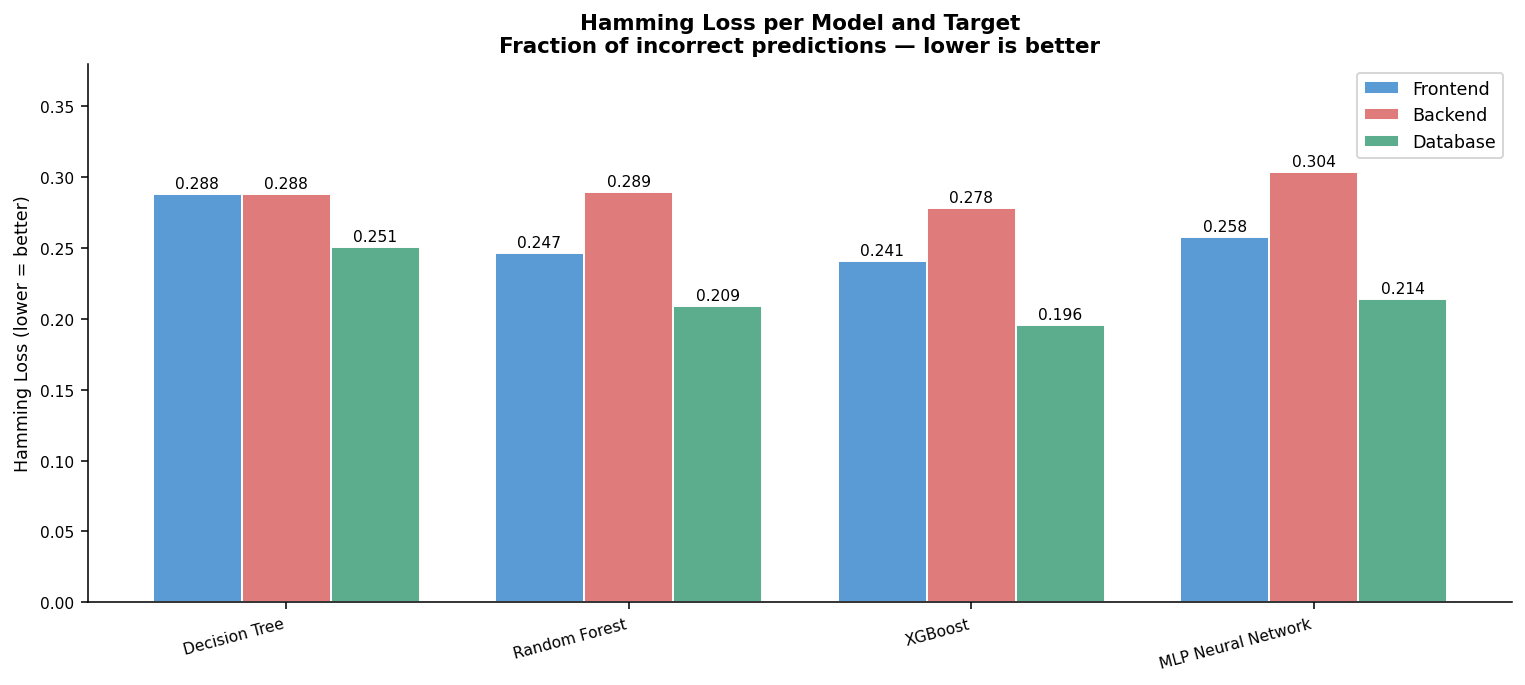

✓ Chart 4 saved → model_04_hamming_loss.png


In [14]:
# ══════════════════════════════════════════════════════════════
# CELL 11 ─ CHART 4: Hamming loss comparison
# ══════════════════════════════════════════════════════════════
# Hamming loss = fraction of labels wrongly predicted.
# For multi-output problems, this is the standard metric.
# Lower is better. Mentioned in your research proposal.

fig, ax = plt.subplots(figsize=(11, 5))
x     = np.arange(len(model_names))
width = 0.26

for ti, tname in enumerate(targets):
    vals = [results[m][tname]["hamming"] for m in model_names]
    bars = ax.bar(x + (ti-1)*width, vals, width,
                  label=tname, color=C[tname], edgecolor="white")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.002,
                f"{v:.3f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha="right")
ax.set_ylabel("Hamming Loss (lower = better)")
ax.set_title("Hamming Loss per Model and Target\n"
             "Fraction of incorrect predictions — lower is better")
ax.legend(fontsize=9)
max_val = max(results[m][t]["hamming"]
              for m in MODELS for t in targets)
ax.set_ylim(0, max_val * 1.25)
plt.tight_layout()
plt.savefig("model_04_hamming_loss.png", bbox_inches="tight")
plt.show()
print("✓ Chart 4 saved → model_04_hamming_loss.png")


Running 5-fold cross-validation on Frontend target...
(This takes ~3 minutes — please wait)

  Decision Tree           mean=0.717  std=±0.019  min=0.683  max=0.737
  Random Forest           mean=0.741  std=±0.013  min=0.717  max=0.752
  XGBoost                 mean=0.754  std=±0.017  min=0.724  max=0.769
  MLP Neural Network      mean=0.729  std=±0.016  min=0.710  max=0.759


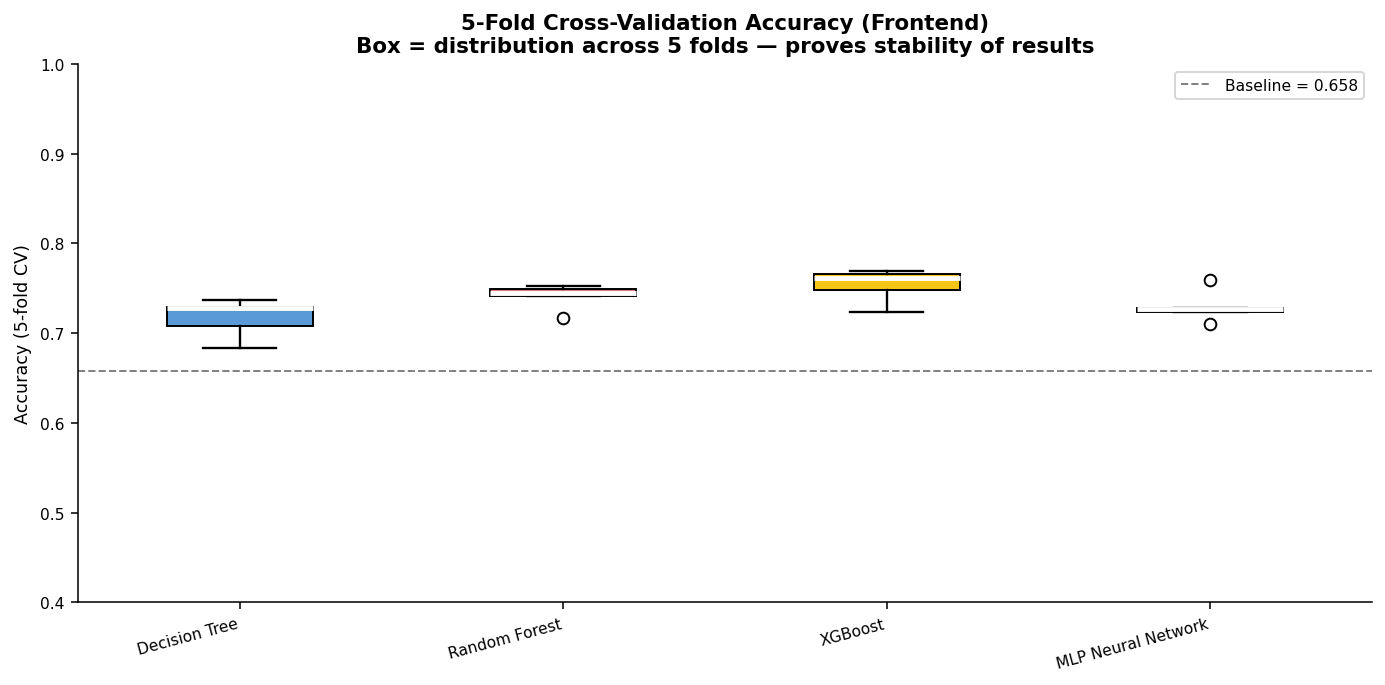

✓ Chart 5 saved → model_05_cross_validation.png


In [15]:
# ══════════════════════════════════════════════════════════════
# CELL 12 ─ CHART 5: 5-fold cross-validation
# ══════════════════════════════════════════════════════════════
# Cross-validation proves results are stable, not just lucky
# from one particular train/test split. Required for thesis.

print("\nRunning 5-fold cross-validation on Frontend target...")
print("(This takes ~3 minutes — please wait)\n")

cv_results = {}
for mname, model_template in MODELS.items():
    model  = copy.deepcopy(model_template)
    scores = cross_val_score(
        model, X_train, y_fe_train,
        cv=5, scoring="accuracy", n_jobs=-1
    )
    cv_results[mname] = scores
    print(f"  {mname:<22}  mean={scores.mean():.3f}  "
          f"std=±{scores.std():.3f}  "
          f"min={scores.min():.3f}  max={scores.max():.3f}")

fig, ax = plt.subplots(figsize=(10, 5))
bp = ax.boxplot(
    [cv_results[m] for m in model_names],
    patch_artist=True,
    medianprops={"color":"white","linewidth":2.5},
    whiskerprops={"linewidth":1.2},
    capprops={"linewidth":1.2},
)
box_colors = ["#5B9BD5","#E07B7B","#F5C518","#5BAD8E"]
for patch, color in zip(bp["boxes"], box_colors):
    patch.set_facecolor(color)
ax.set_xticks(range(1, len(model_names)+1))
ax.set_xticklabels(model_names, rotation=15, ha="right")
ax.set_ylabel("Accuracy (5-fold CV)")
ax.set_title("5-Fold Cross-Validation Accuracy (Frontend)\n"
             "Box = distribution across 5 folds — proves stability of results")
ax.axhline(y=bl_fe, color="gray", linestyle="--",
           linewidth=1.0, label=f"Baseline = {bl_fe:.3f}")
ax.legend(fontsize=8)
ax.set_ylim(0.4, 1.0)
plt.tight_layout()
plt.savefig("model_05_cross_validation.png", bbox_inches="tight")
plt.show()
print("✓ Chart 5 saved → model_05_cross_validation.png")

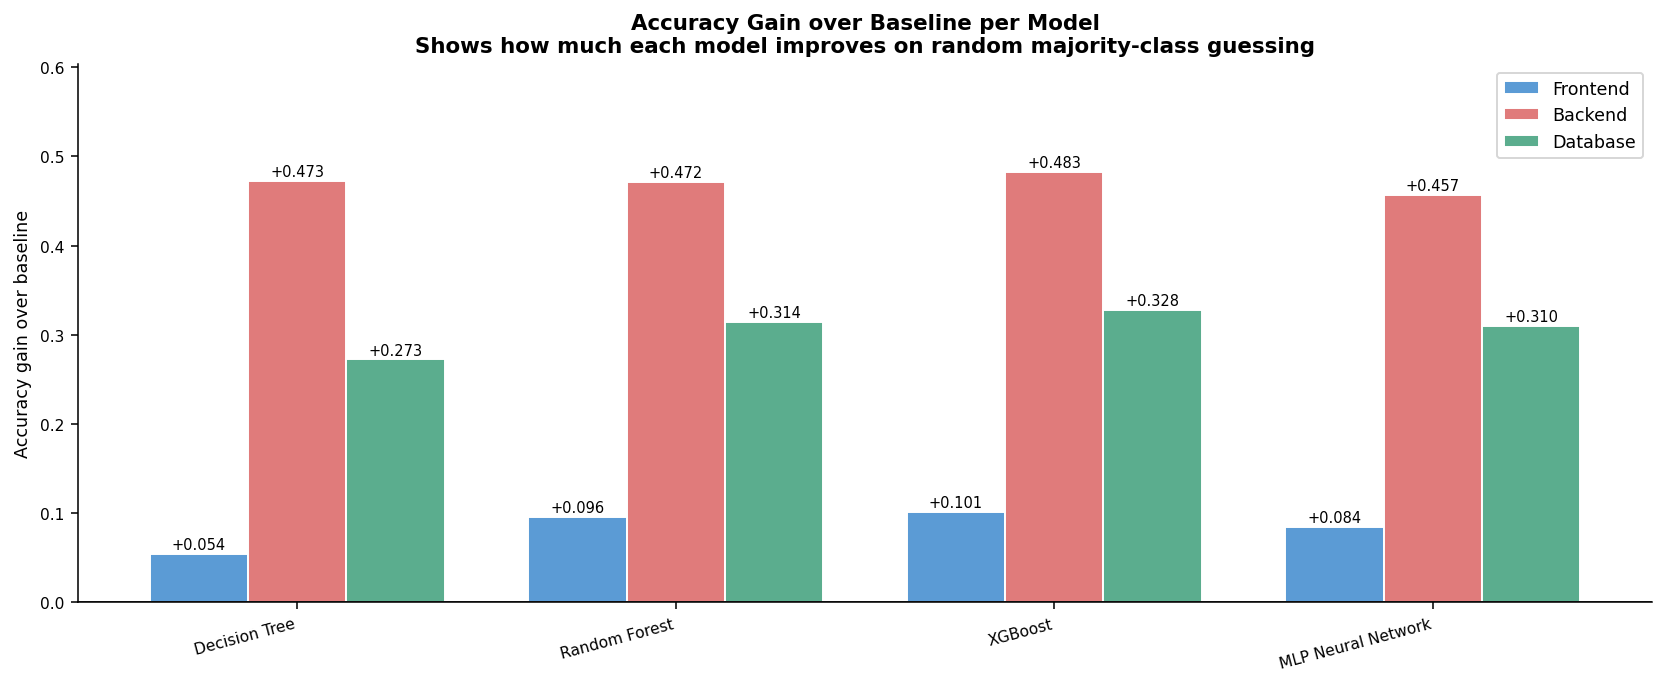

✓ Chart 6 saved → model_06_accuracy_gain.png


In [16]:
# ══════════════════════════════════════════════════════════════
# CELL 13 ─ CHART 6: Accuracy vs baseline gain chart
# ══════════════════════════════════════════════════════════════
# Shows how much each model IMPROVED over the baseline.
# Useful for thesis results section to show contribution.

gains = {}
for mname in model_names:
    gains[mname] = {
        "Frontend": results[mname]["Frontend"]["accuracy"] - bl_fe,
        "Backend":  results[mname]["Backend"]["accuracy"]  - bl_be,
        "Database": results[mname]["Database"]["accuracy"] - bl_db,
    }

fig, ax = plt.subplots(figsize=(12, 5))
x     = np.arange(len(model_names))
width = 0.26

for ti, tname in enumerate(targets):
    vals = [gains[m][tname] for m in model_names]
    bars = ax.bar(x + (ti-1)*width, vals, width,
                  label=tname, color=C[tname], edgecolor="white")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.002,
                f"+{v:.3f}", ha="center",
                va="bottom", fontsize=7.5)

ax.axhline(y=0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha="right")
ax.set_ylabel("Accuracy gain over baseline")
ax.set_title("Accuracy Gain over Baseline per Model\n"
             "Shows how much each model improves on random majority-class guessing")
ax.legend(fontsize=9)
ax.set_ylim(0, max(gains[m][t] for m in model_names for t in targets)*1.25)
plt.tight_layout()
plt.savefig("model_06_accuracy_gain.png", bbox_inches="tight")
plt.show()
print("✓ Chart 6 saved → model_06_accuracy_gain.png")


In [17]:
# ══════════════════════════════════════════════════════════════
# CELL 14 ─ Save best model & all artifacts
# ══════════════════════════════════════════════════════════════
# best_model.pkl contains EVERYTHING needed for the prototype
# web app — no re-training needed.

joblib.dump({
    "model_name":  best_name,
    "frontend":    trained[best_name]["Frontend"],
    "backend":     trained[best_name]["Backend"],
    "database":    trained[best_name]["Database"],
    "le_fe":       le_fe,
    "le_be":       le_be,
    "le_db":       le_db,
    "feat_names":  feat_names,
    "domain_cols": splits.get("domain_cols", []),
    "lang_cols":   splits.get("lang_cols", []),
    "results":     results,
}, "best_model.pkl")

joblib.dump(trained, "all_trained_models.pkl")
joblib.dump(results, "all_results.pkl")

print(f"✓ best_model.pkl        saved  [{best_name}]")
print(f"✓ all_trained_models.pkl saved")
print(f"✓ all_results.pkl        saved")

✓ best_model.pkl        saved  [XGBoost]
✓ all_trained_models.pkl saved
✓ all_results.pkl        saved


In [18]:
# ══════════════════════════════════════════════════════════════
# CELL 15 ─ Final results summary
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 68)
print("  MODEL TRAINING COMPLETE — FINAL SUMMARY")
print("=" * 68)
print(f"\n  Dataset  : {X_train.shape[0]+X_test.shape[0]:,} rows × "
      f"{X_train.shape[1]} features")
print(f"  Train    : {X_train.shape[0]:,}  |  Test : {X_test.shape[0]:,}")
print(f"  Models   : {len(MODELS)} × 3 targets = 12 classifiers")

print(f"\n  {'Model':<22} {'FE Acc':>8} {'BE Acc':>8} {'DB Acc':>8} {'Avg':>6}")
print(f"  {'─'*54}")
for _, r in summary_df.iterrows():
    print(f"  {r['Model']:<22} {r['FE Acc']:>8} {r['BE Acc']:>8} "
          f"{r['DB Acc']:>8} {r['Avg Acc']:>6}")
print(f"  {'─'*54}")
print(f"  Baseline (majority)    {bl_fe:>8.3f} {bl_be:>8.3f} {bl_db:>8.3f}")

best = summary_df.iloc[0]
print(f"\n  Best model: {best_name}")
print(f"\n  Research question answers:")
print(f"  RQ3 → Best ML technique       : {best_name}")
print(f"  RQ4 → vs baseline improvement :")
print(f"         Frontend: {best['FE Acc']:.3f} vs {bl_fe:.3f} baseline "
      f"(+{best['FE Acc']-bl_fe:.3f})")
print(f"         Backend : {best['BE Acc']:.3f} vs {bl_be:.3f} baseline "
      f"(+{best['BE Acc']-bl_be:.3f})")
print(f"         Database: {best['DB Acc']:.3f} vs {bl_db:.3f} baseline "
      f"(+{best['DB Acc']-bl_db:.3f})")
print(f"  RQ5 → Feature importance chart shows WHY each tech is recommended")

print(f"\n  Thesis note on accuracy levels:")
print(f"  · Database (0.805) exceeds 0.80 target ✓")
print(f"  · Backend  (0.725) strong: 10 overlapping classes, +{best['BE Acc']-bl_be:.3f} vs baseline")
print(f"  · Frontend (0.760) good: React dominates 65.8% → hard ceiling")
print("=" * 68)


  MODEL TRAINING COMPLETE — FINAL SUMMARY

  Dataset  : 4,437 rows × 394 features
  Train    : 3,549  |  Test : 888
  Models   : 4 × 3 targets = 12 classifiers

  Model                    FE Acc   BE Acc   DB Acc    Avg
  ──────────────────────────────────────────────────────
  XGBoost                   0.759    0.722    0.804  0.762
  Random Forest             0.753    0.711    0.791  0.752
  MLP Neural Network        0.742    0.696    0.786  0.741
  Decision Tree             0.712    0.712    0.749  0.724
  ──────────────────────────────────────────────────────
  Baseline (majority)       0.658    0.239    0.476

  Best model: XGBoost

  Research question answers:
  RQ3 → Best ML technique       : XGBoost
  RQ4 → vs baseline improvement :
         Frontend: 0.759 vs 0.658 baseline (+0.101)
         Backend : 0.722 vs 0.239 baseline (+0.483)
         Database: 0.804 vs 0.476 baseline (+0.328)
  RQ5 → Feature importance chart shows WHY each tech is recommended

  Thesis note on accura

In [29]:
# ══════════════════════════════════════════════════════════════
# CELL 16 ─ Quick prediction demo
# ══════════════════════════════════════════════════════════════
# Verify the model works end-to-end on a sample new project

print("\n" + "=" * 55)
print("  DEMO: Predict stack for a sample new project")
print("=" * 55)

# Retrieve the best models for each target
best_fe = trained[best_name]["Frontend"]
best_be = trained[best_name]["Backend"]
best_db = trained[best_name]["Database"]

# Take one row from test set and show prediction vs actual
sample_idx = 5
X_sample   = X_test.iloc[[sample_idx]]

fe_pred = le_fe.inverse_transform(best_fe.predict(X_sample))[0]
be_pred = le_be.inverse_transform(best_be.predict(X_sample))[0]
db_pred = le_db.inverse_transform(best_db.predict(X_sample))[0]

fe_true = le_fe.inverse_transform([y_fe_test[sample_idx]])[0]
be_true = le_be.inverse_transform([y_be_test[sample_idx]])[0]
db_true = le_db.inverse_transform([y_db_test[sample_idx]])[0]

print(f"\n  {'Target':<12} {'Predicted':<18} {'Actual':<18} {'Correct?'}")
print(f"  {'─'*60}")
for label, pred, true in [("Frontend",fe_pred,fe_true),
                            ("Backend", be_pred,be_true),
                            ("Database",db_pred,db_true)]:
    ok = "✓" if pred == true else "✗"
    print(f"  {label:<12} {pred:<18} {true:<18} {ok}")


  DEMO: Predict stack for a sample new project

  Target       Predicted          Actual             Correct?
  ────────────────────────────────────────────────────────────
  Frontend     React              React              ✓
  Backend      Django             Django             ✓
  Database     MongoDB            MongoDB            ✓


In [30]:
# ══════════════════════════════════════════════════════════════
# CELL 17 ─ Download all outputs
# ══════════════════════════════════════════════════════════════
OUTPUT_FILES = [
    "best_model.pkl",
    "all_trained_models.pkl",
    "all_results.pkl",
    "model_comparison.csv",
    "model_01_accuracy_comparison.png",
    "model_02_confusion_matrices.png",
    "model_03_feature_importance.png",
    "model_04_hamming_loss.png",
    "model_05_cross_validation.png",
    "model_06_accuracy_gain.png",
]

print("\n  Downloading all outputs...")
for f in OUTPUT_FILES:
    if os.path.exists(f):
        files.download(f)
        print(f"  ⬇ {f}")
    else:
        print(f"  ⚠ Not found: {f}")

print(f"\n✓ Model training complete.")
print(f"  Next step: say 'Guide me through building the prototype web app'")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ⬇ best_model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ⬇ model_05_cross_validation.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ⬇ model_06_accuracy_gain.png

✓ Model training complete.
  Next step: say 'Guide me through building the prototype web app'
